In [1]:
import cv2
import numpy as np
import glob
import matplotlib.pyplot as plt

## Helper Methods and Segmentation Code

In [2]:
def load_images(folder):
    paths = glob.glob(folder + "/*")
    images = []

    for path in paths:
        img = cv2.imread(path)
        if img is not None:
            images.append(img)

    return images

def compute_background(images):
    stack = np.stack(images, axis=0)
    background = np.median(stack, axis=0).astype(np.uint8)
    return background

def load_roi_mask(path):
    roi = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    _, roi = cv2.threshold(roi, 127, 255, cv2.THRESH_BINARY)
    return roi

def compute_reflection_mask(image, v_thresh, s_thresh):
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv)

    reflection_mask = np.zeros_like(v, dtype=np.uint8)
    reflection_mask[(v >= v_thresh) & (s <= s_thresh)] = 255

    kernel = np.ones((7, 7), np.uint8)
    reflection_mask = cv2.morphologyEx(reflection_mask, cv2.MORPH_CLOSE, kernel)
    reflection_mask = cv2.morphologyEx(reflection_mask, cv2.MORPH_OPEN, kernel)

    return reflection_mask

def suppress_reflections_from_mask(mask, reflection_mask):
    reflection_inv = cv2.bitwise_not(reflection_mask)
    cleaned_mask = cv2.bitwise_and(mask, reflection_inv)
    return cleaned_mask

def segment_debris(image, background, roi_mask, threshold=30):
    image_blur = cv2.GaussianBlur(image, (7, 7), 0)
    background_blur = cv2.GaussianBlur(background, (7, 7), 0)

    diff = cv2.absdiff(image_blur, background_blur)
    diff_gray = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)

    _, mask = cv2.threshold(diff_gray, threshold, 255, cv2.THRESH_BINARY)

    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.bitwise_and(mask, roi_mask)

    return mask

def segment_debris_with_reflection_rejection(image, background, roi_mask, threshold=30, v_thresh=220, s_thresh=60):
    image_blur = cv2.GaussianBlur(image, (7, 7), 0)
    background_blur = cv2.GaussianBlur(background, (7, 7), 0)

    diff = cv2.absdiff(image_blur, background_blur)
    diff_gray = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)

    _, raw_mask = cv2.threshold(diff_gray, threshold, 255, cv2.THRESH_BINARY)

    kernel = np.ones((5, 5), np.uint8)
    raw_mask = cv2.morphologyEx(raw_mask, cv2.MORPH_OPEN, kernel)
    raw_mask = cv2.morphologyEx(raw_mask, cv2.MORPH_CLOSE, kernel)
    raw_mask = cv2.bitwise_and(raw_mask, roi_mask)

    reflection_mask = compute_reflection_mask(image, v_thresh, s_thresh)
    reflection_mask = cv2.bitwise_and(reflection_mask, roi_mask)

    final_mask = suppress_reflections_from_mask(raw_mask, reflection_mask)

    return raw_mask, reflection_mask, final_mask

def show_background(background):
    background_rgb = cv2.cvtColor(background, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(7, 7))
    plt.imshow(background_rgb)
    plt.title("Background")
    plt.axis("off")
    plt.show()

def show_results(image, mask, reflection_mask, final_mask, show_reflection_mask=False):
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    reflection_overlay = image_rgb.copy()
    reflection_overlay[reflection_mask > 0] = [0, 0, 255]

    debris_overlay = image_rgb.copy()
    debris_overlay[mask > 0] = [255, 0, 0]

    final_overlay = image_rgb.copy()
    final_overlay[final_mask > 0] = [255, 0, 0]

    plt.figure(figsize=(18, 6))

    if show_reflection_mask:
        plt.subplot(1, 4, 1)
        plt.imshow(image_rgb)
        plt.title("Input image")
        plt.axis("off")

        plt.subplot(1, 4, 2)
        plt.imshow(debris_overlay)
        plt.title("Raw debris mask")
        plt.axis("off")

        plt.subplot(1, 4, 3)
        plt.imshow(reflection_overlay)
        plt.title("Detected reflections")
        plt.axis("off")

        plt.subplot(1, 4, 4)
        plt.imshow(final_overlay)
        plt.title("Debris after reflection removal")
        plt.axis("off")
    else:
        plt.subplot(1, 3, 1)
        plt.imshow(image_rgb)
        plt.title("Input image")
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.imshow(debris_overlay)
        plt.title("Raw debris mask")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.imshow(final_overlay)
        plt.title("Debris after reflection removal")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

## Testing Different Brightness and Saturation Thresholds for Reflection Removal

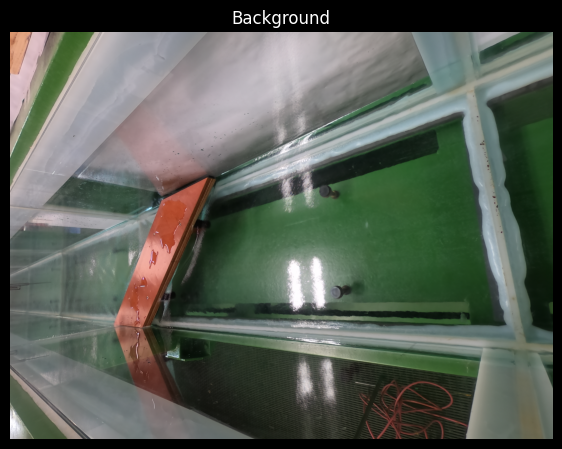

V threshold: 220, S threshold: 60


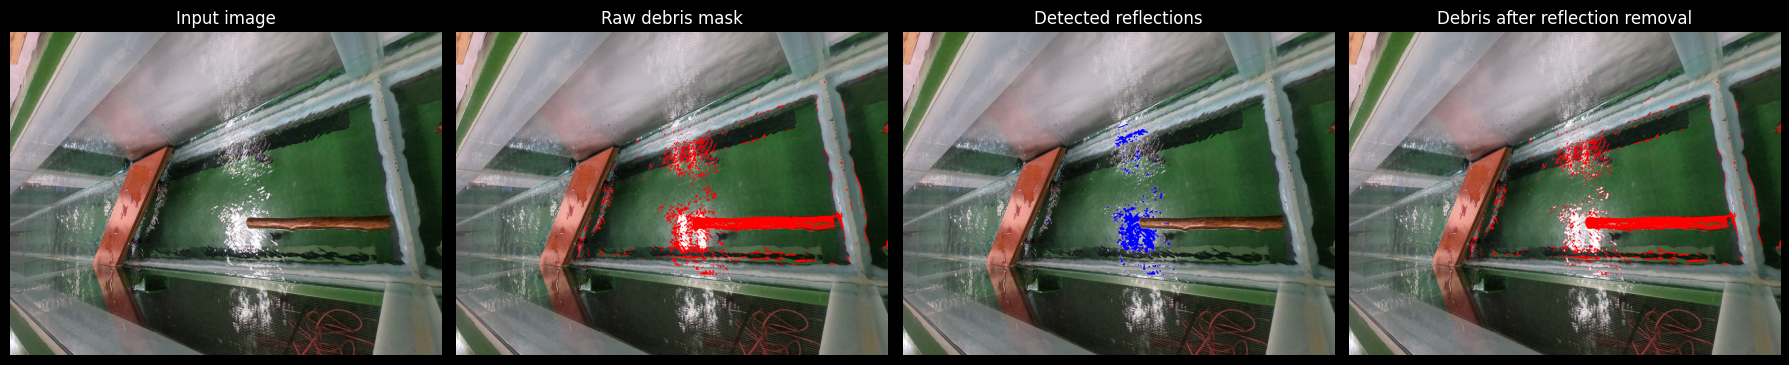

V threshold: 210, S threshold: 75


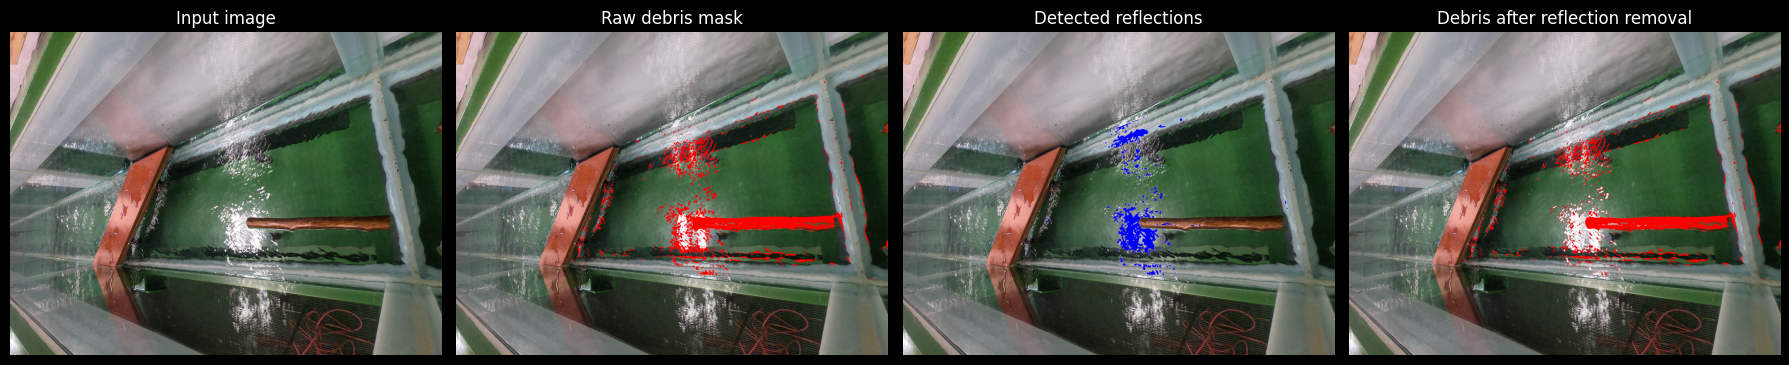

V threshold: 200, S threshold: 90


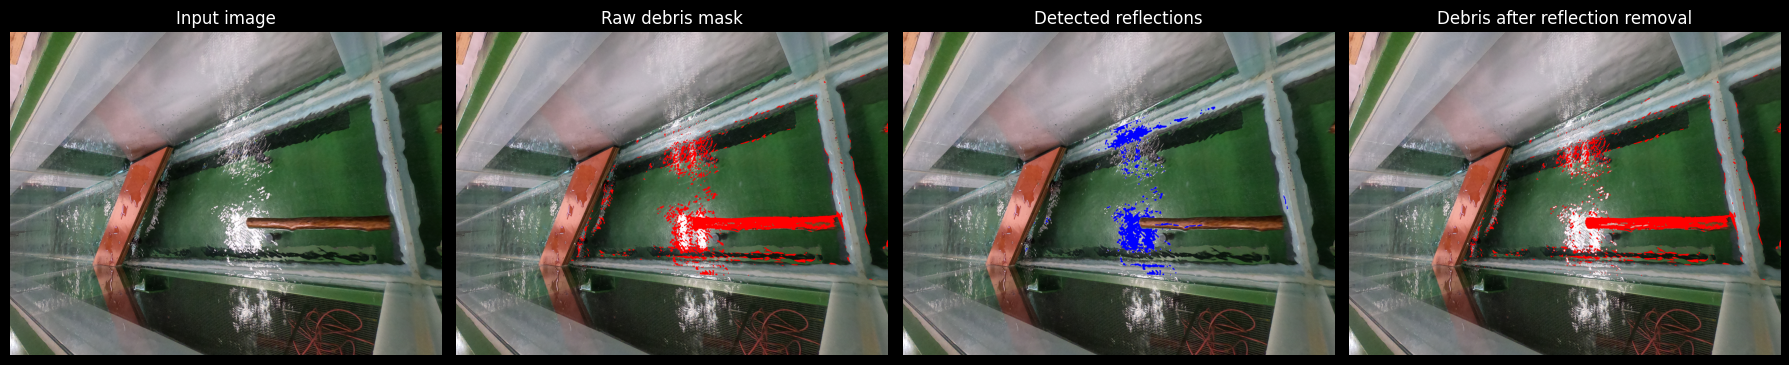

V threshold: 190, S threshold: 105


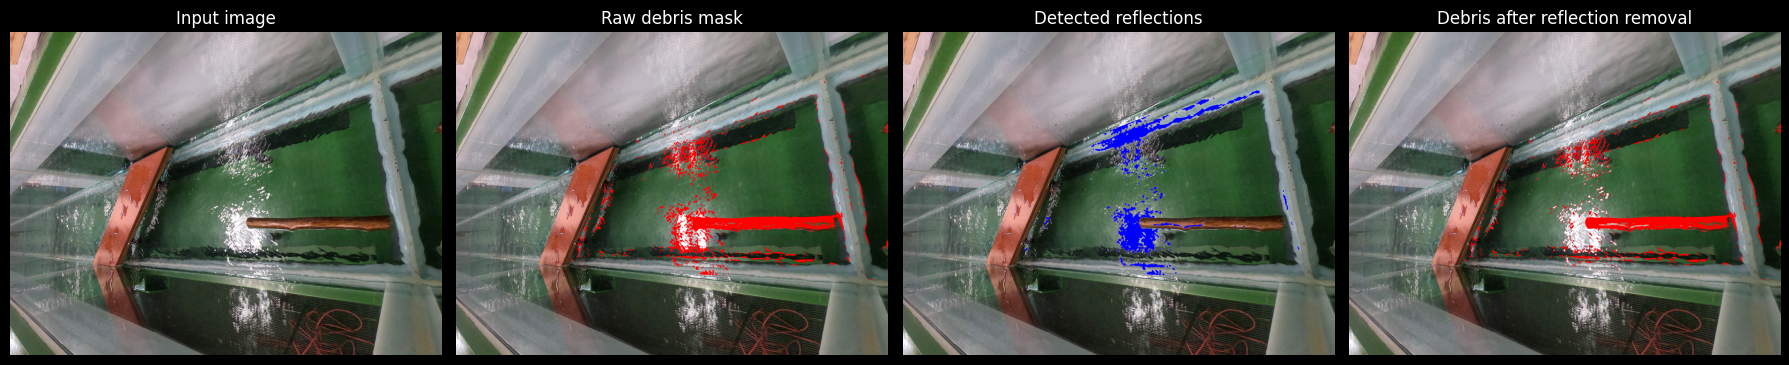

V threshold: 180, S threshold: 120


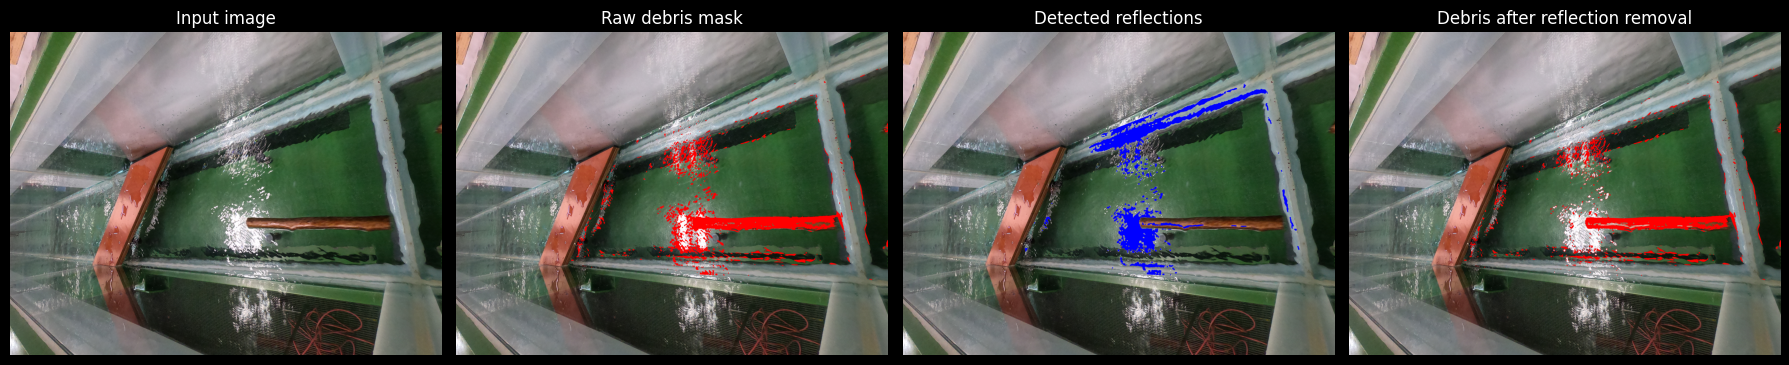

V threshold: 170, S threshold: 135


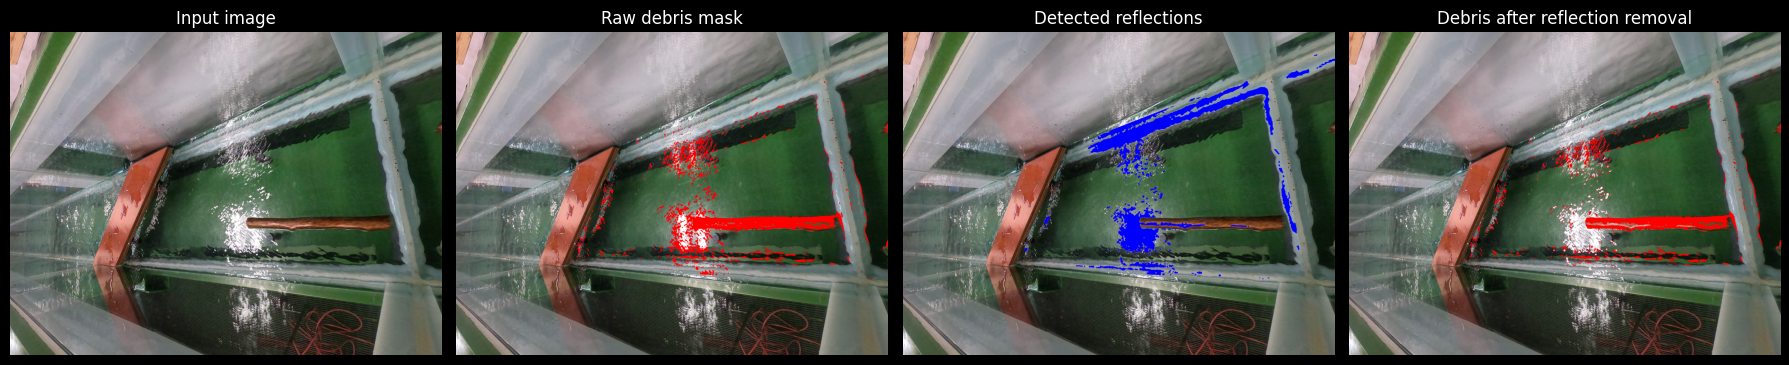

In [3]:
empty_images = load_images("diagonal_empty")
roi_mask = load_roi_mask("roi_masks/diagonal_roi_mask_G0024910.png")
background = compute_background(empty_images)
show_background(background)
test_image = cv2.imread("diagonal_with_debris/G0034935.JPG")
vs_thresholds = [(220, 60), (210, 75), (200, 90), (190, 105), (180, 120), (170, 135)]

for v_thresh, s_thresh in vs_thresholds:
    print(f"V threshold: {v_thresh}, S threshold: {s_thresh}")
    raw_mask, reflection_mask, final_mask = segment_debris_with_reflection_rejection(test_image, background, roi_mask, threshold=30, v_thresh=v_thresh, s_thresh=s_thresh)
    show_results(test_image, raw_mask, reflection_mask, final_mask, show_reflection_mask=True)

## Testing Background Removal On Diaginal View Images

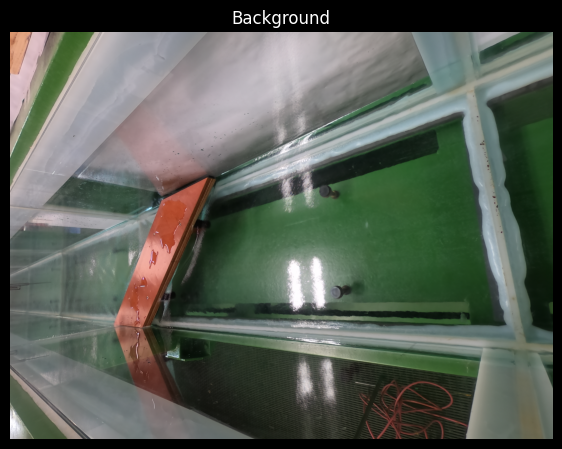

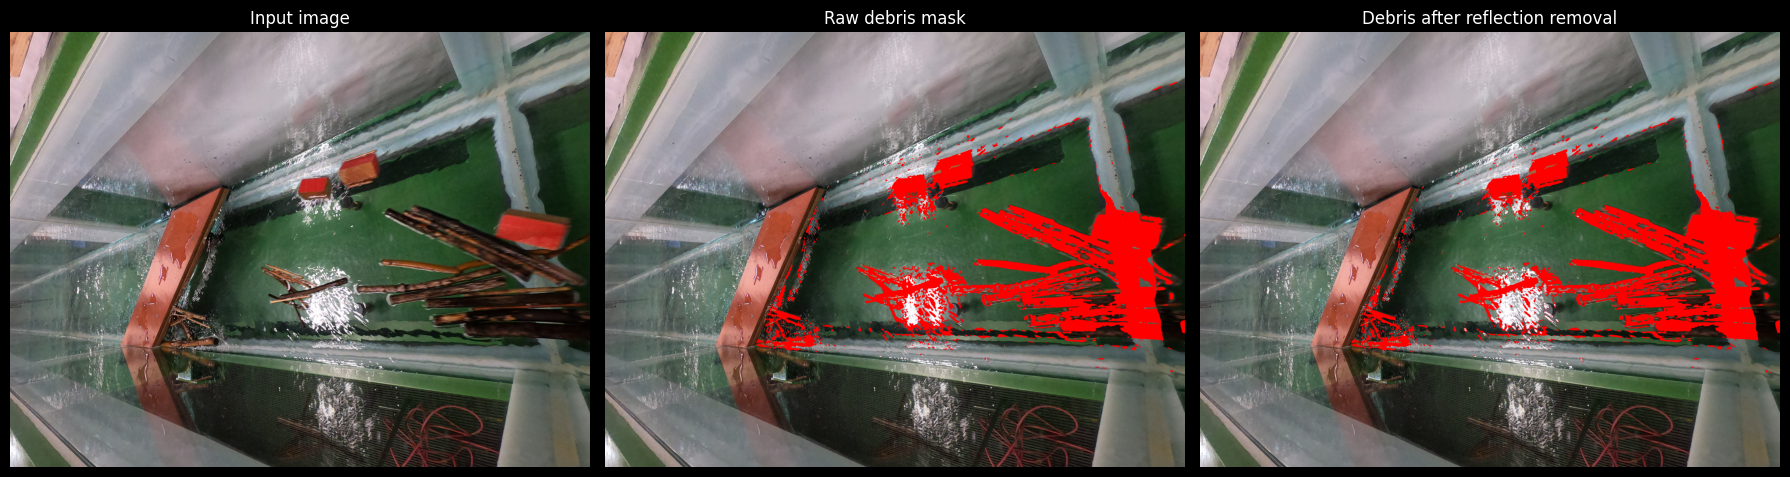

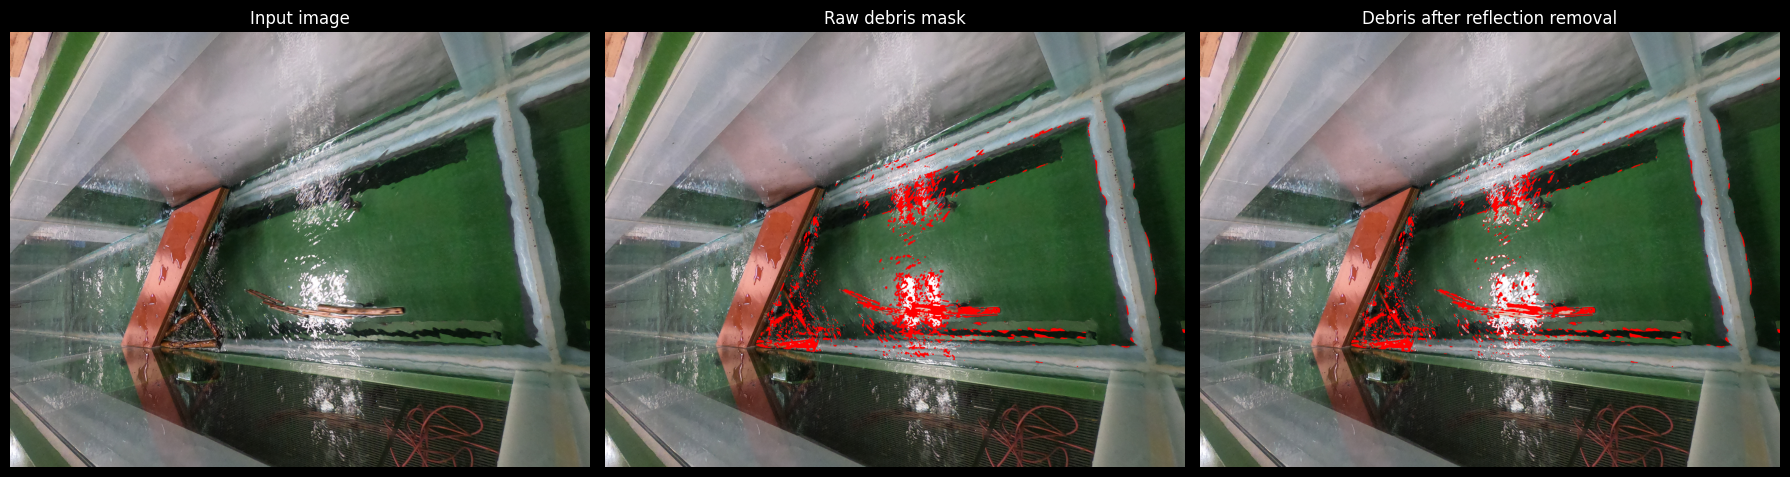

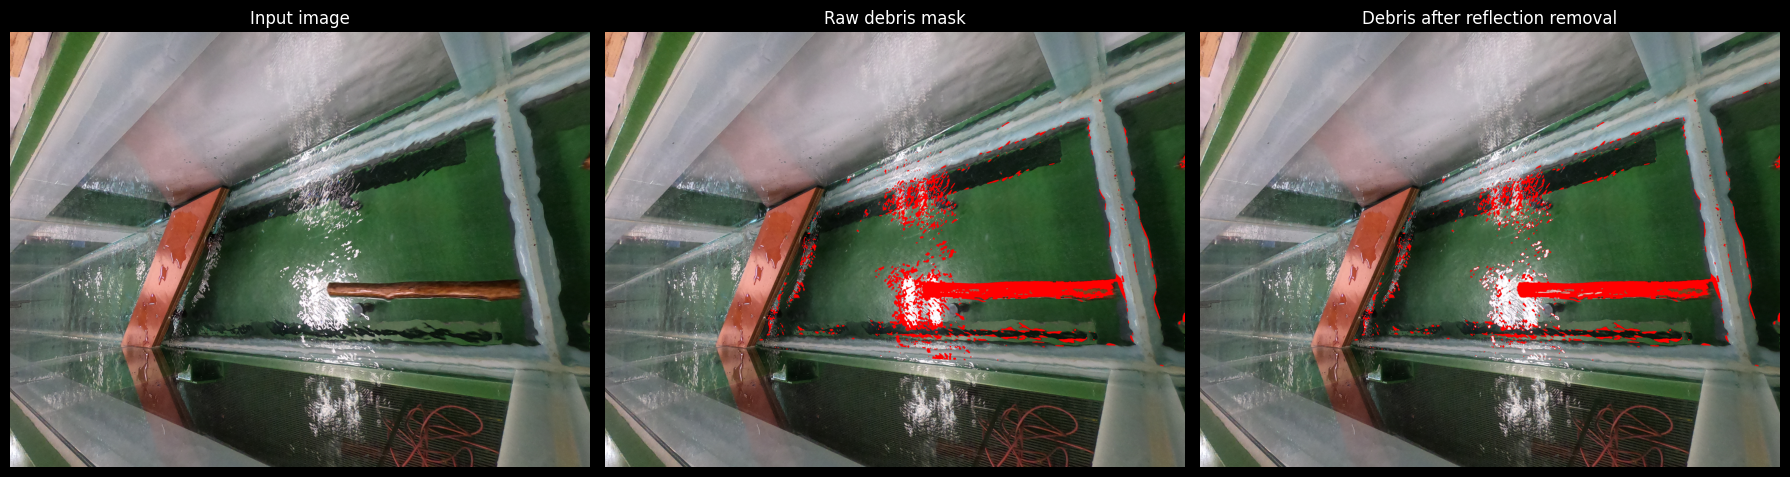

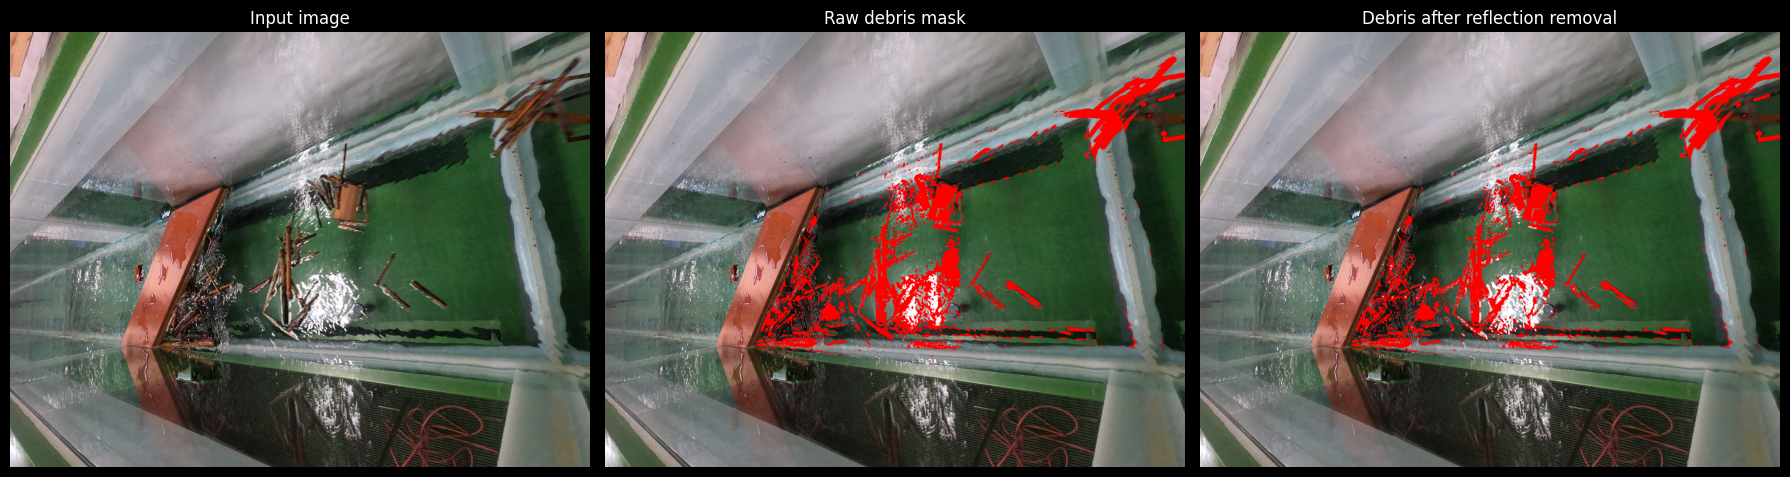

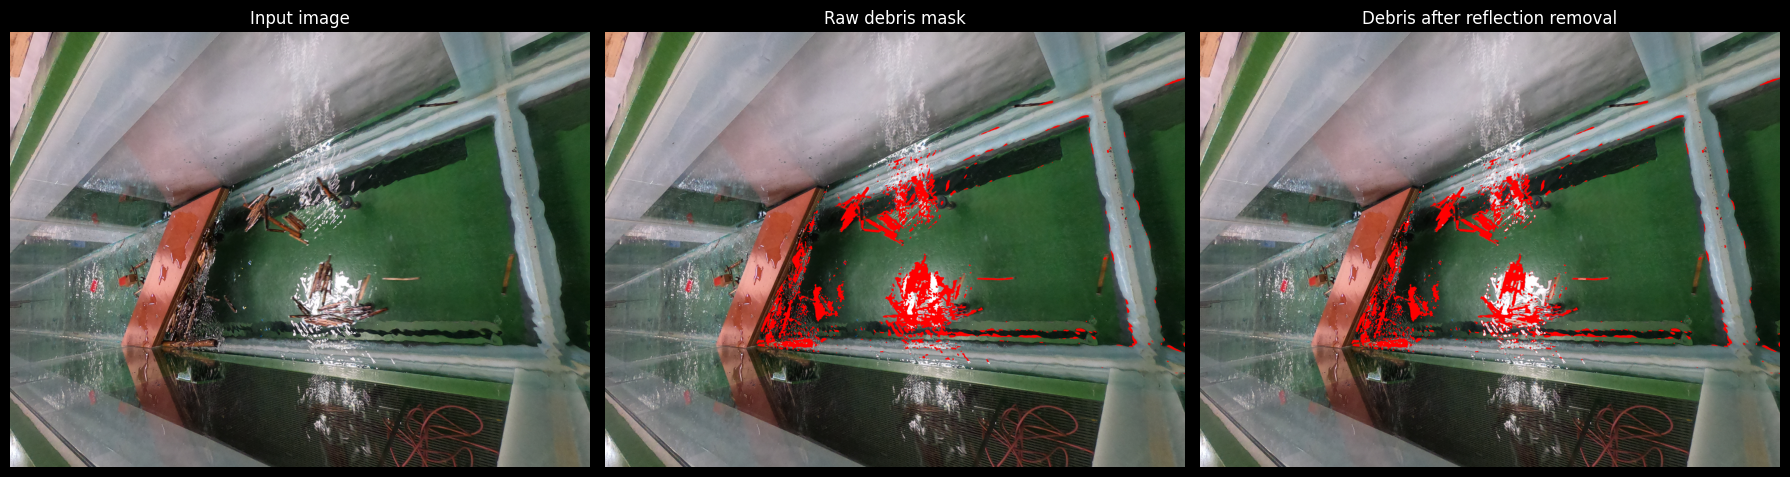

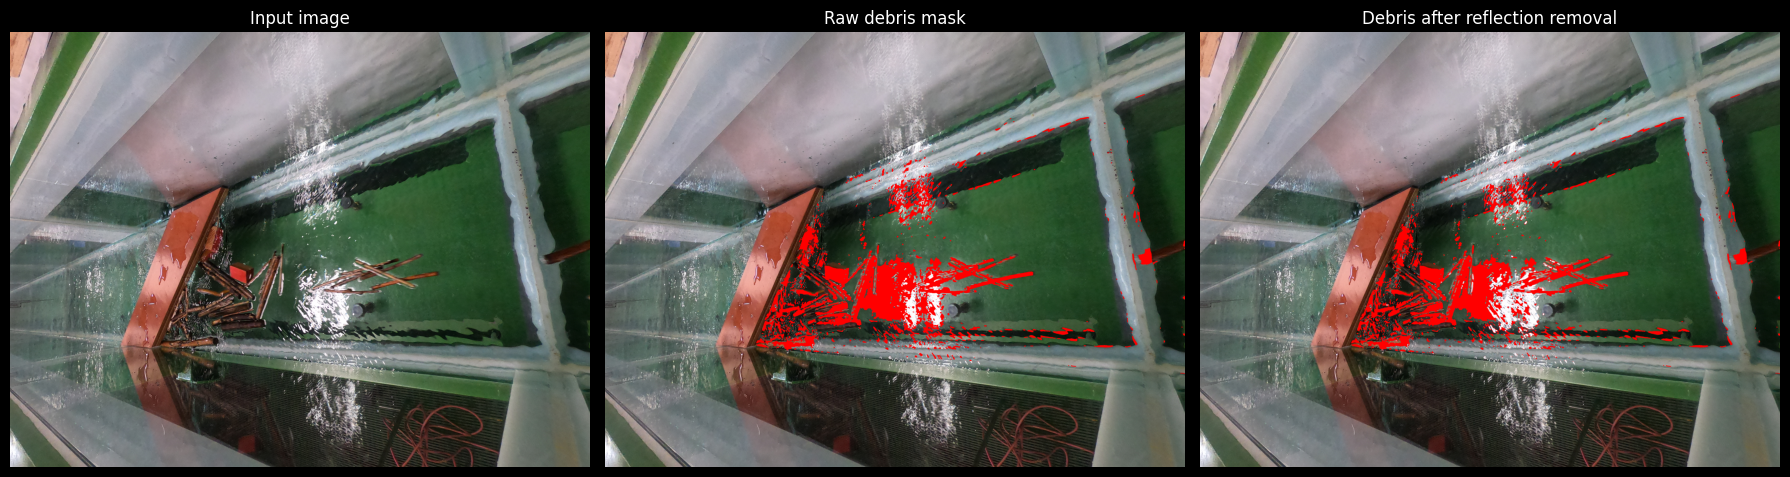

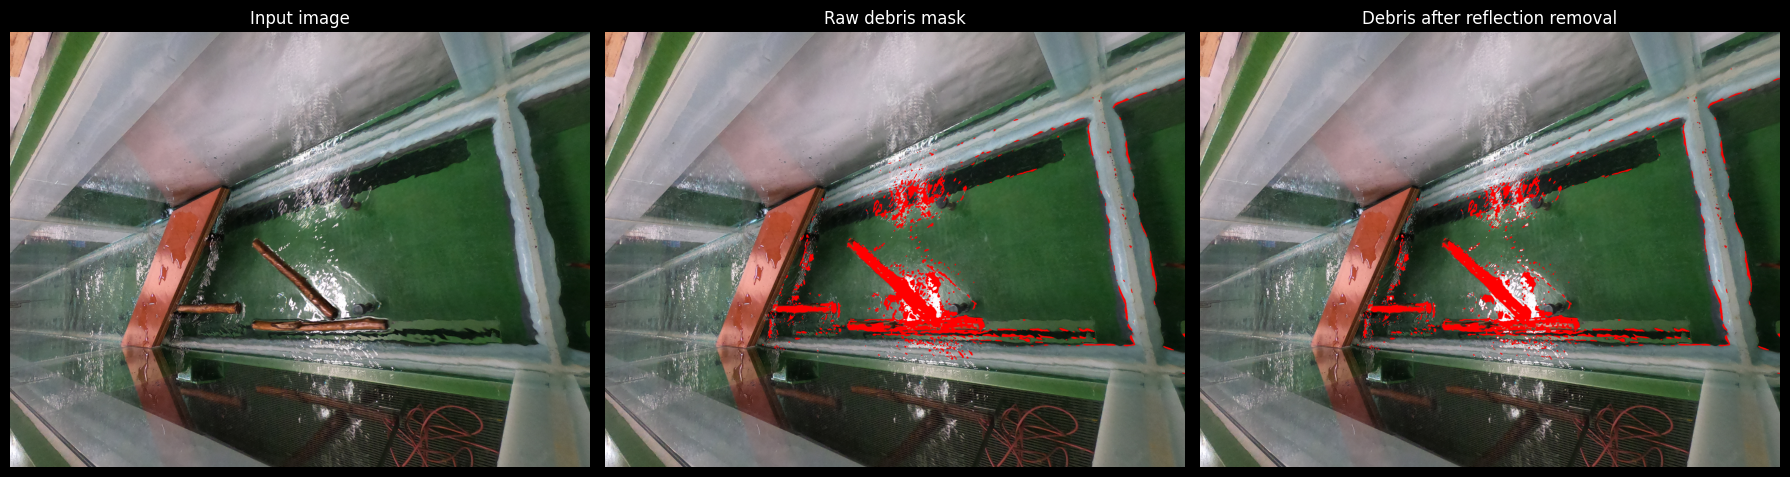

In [4]:
test_paths = glob.glob("diagonal_with_debris/*")
show_background(background)
v_thresh = 200
s_thresh = 90

for path in test_paths:
    img = cv2.imread(path)
    if img is None:
        continue
    raw_mask, reflection_mask, final_mask = segment_debris_with_reflection_rejection(img, background, roi_mask, threshold=30, v_thresh=v_thresh, s_thresh=s_thresh)
    show_results(img, raw_mask, reflection_mask, final_mask)